In [1]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

from lowRank.NMLRSSE_Test import NMLRSSE_Test_SVD
from lowRank import compute_expectation as ce
from utils.noise_generator import ColoredNoiseGenerator_Cholesky
from utils import multi_index

# bath correlation function constructed by lambda*V_dag*V
lamda = 1
gamma = 1
omega  = 0.5
V_func = lambda t: np.exp(-(gamma + 1j*omega)*t)
alpha = lambda t,s: lamda * np.conj(V_func(t)) * V_func(s)

# spin-boson model parameters
Delta = 1
eps = [0, Delta, 2*Delta]
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
Hs = [Delta*sx + e*sz for e in eps]
L = sz

Trajectories: 100%|██████████| 10000/10000 [00:08<00:00, 1160.23it/s]


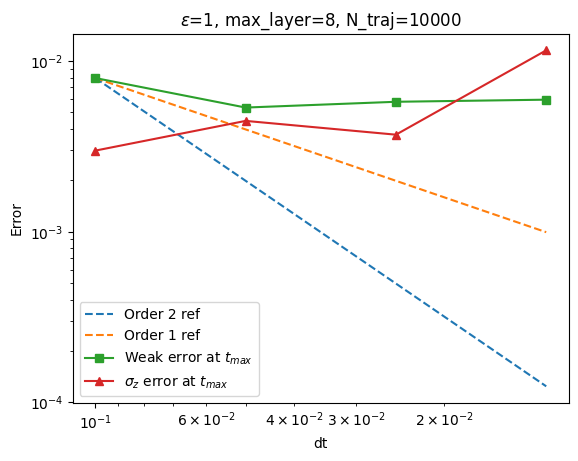

In [ ]:
example = 1
# parameters for the simulation
base = 50
tmax = 5.0 / Delta
N_steps = np.array([1, 2, 4, 8]) * base
ref_N_steps = 1600
psi0 = np.array([1.0, 0.0], dtype=complex)
N_traj = 10000
max_layer = 8
parallel_traj = False

# For test
z_func = lambda t: np.exp(-(gamma - 1j*omega)*t)

z = np.array([z_func(t) for t in np.linspace(0, tmax, ref_N_steps + 1)], dtype=complex)
Z = np.empty((N_traj, ref_N_steps + 1), dtype=np.complex128)
for traj in range(N_traj):
    xi = (np.random.randn() + 1j * np.random.randn()) / np.sqrt(2)
    Z[traj, :] = xi * z
solver = NMLRSSE_Test_SVD(
    Hs = Hs[example],
    L = L,
    V = V_func,
    lamda = lamda,
    tmax = tmax,
    N_steps = ref_N_steps,
    max_layer = max_layer,
    noise_sample_Z = Z,
)
ref_psis = solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
ref_psi_end = ref_psis[:, -1, :]
ref_psi_end_ex = np.mean(ref_psi_end, axis=0)
ref_sigma_z = ce.compute_expectation_value_linear(ref_psis, sz)

strong_error_end = []
weak_error_end = []
sigma_z_error_end = []
for steps in N_steps:
    z = np.array([z_func(t) for t in np.linspace(0, tmax, steps + 1)], dtype=complex)
    Z = np.empty((N_traj, steps + 1), dtype=np.complex128)
    for traj in range(N_traj):
        xi = (np.random.randn() + 1j * np.random.randn()) / np.sqrt(2)
        Z[traj, :] = xi * z
    # Z_cur = Z[:, ::ref_N_steps//steps]
    solver = NMLRSSE_Test_SVD(
        Hs = Hs[example],
        L = L,
        V = V_func,
        lamda = lamda,
        tmax = tmax,
        N_steps = steps,
        max_layer = max_layer,
        noise_sample_Z = Z,
    )
    psis = solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
    psi_end = psis[:, -1, :]
    sigma_z = ce.compute_expectation_value_linear(psis, sz)
    strong_err_end = np.mean(np.linalg.norm(psi_end - ref_psi_end, axis=1))
    strong_error_end.append(strong_err_end)
    weak_err_end = np.linalg.norm(np.mean(psi_end, axis=0) - ref_psi_end_ex)
    weak_error_end.append(weak_err_end)
    sigma_z_error_end.append(np.abs(sigma_z[-1] - ref_sigma_z[-1]))

h = tmax/np.array(N_steps)
c_ref = weak_error_end[0] / (h[0])**2
ref_line = c_ref * (h**2)
plt.loglog(h, ref_line, '--', label='Order 2 ref')
c_ref = weak_error_end[0] / (h[0])
ref_line = c_ref * (h)
plt.loglog(h, ref_line, '--', label='Order 1 ref')
plt.loglog(h, weak_error_end, marker='s', label=r'Weak error at $t_{max}$')
# plt.loglog(h, strong_error_end, marker='o', label=r'Strong error at $t_{max}$')
plt.loglog(h, sigma_z_error_end, marker='^', label=r'$\sigma_z$ error at $t_{max}$')
plt.xlabel('dt')
plt.ylabel('Error')
plt.gca().invert_xaxis()
plt.title(r'$\epsilon$={}, max_layer={}, N_traj={}'.format(eps[example], max_layer, N_traj))
plt.legend()
plt.show()